In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/luisjaneirobezi/hotel-bookings/hotel_bookings.csv


In [2]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import plotly.express as px

# LIMPIEZA

In [3]:
df = pd.read_csv("/kaggle/input/datasets/luisjaneirobezi/hotel-bookings/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [5]:
df.shape

(119390, 32)

In [6]:
df = df[df["is_canceled"] == 0]
df.shape

(75166, 32)

In [7]:
df["room_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

In [8]:
df["revenue"] = df["adr"] * df["room_nights"]
df[["adr","room_nights","revenue"]].head()

,adr,room_nights,revenue
0,0.0,0,0.0
1,0.0,0,0.0
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0


In [9]:
df = df[df["revenue"] > 0]
df[["adr","room_nights","revenue"]].head()

,adr,room_nights,revenue
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0
5,98.0,2,196.0
6,107.0,2,214.0


In [10]:
df = df[(df["adr"] > 0) & (df["adr"] < 2000)]

In [11]:
month_map = {
"January":1,"February":2,"March":3,"April":4,
"May":5,"June":6,"July":7,"August":8,
"September":9,"October":10,"November":11,"December":12
}

df["month_number"] = df["arrival_date_month"].map(month_map)

In [12]:
df["arrival_date"] = pd.to_datetime(dict(
    year=df["arrival_date_year"],
    month=df["month_number"],
    day=df["arrival_date_day_of_month"]
))
df[["arrival_date"]].head()

,arrival_date
2,2015-07-01
3,2015-07-01
4,2015-07-01
5,2015-07-01
6,2015-07-01


In [13]:
def define_season(m):

    if m in [6,7,8,9]:
        return "High"

    elif m in [4,5,10]:
        return "Shoulder"

    else:
        return "Low"

df["season"] = df["month_number"].apply(define_season)
df["season"].value_counts()

season
High        28806
Low         24492
Shoulder    20121
Name: count, dtype: int64

Construcción de demanda diaria# 

In [14]:
daily = df.groupby(["arrival_date","season"]).agg({
    "room_nights":"sum",
    "revenue":"sum"
}).reset_index()

In [15]:
daily["ADR"] = daily["revenue"] / daily["room_nights"]
daily.head()

,arrival_date,season,room_nights,revenue,ADR
0,2015-07-01,High,312,28404.76,91.040897
1,2015-07-02,High,205,19614.45,95.680244
2,2015-07-03,High,160,15756.98,98.481125
3,2015-07-04,High,238,21583.04,90.685042
4,2015-07-05,High,226,23756.85,105.118805


In [16]:
daily.shape

(793, 5)

In [17]:
daily["ADR"].describe()

count    793.000000
mean      98.762387
std       30.091378
min       44.005263
25%       74.885194
50%       93.294457
75%      119.414846
max      179.252113
Name: ADR, dtype: float64

The average ADR during the period is approximately €98.8.
Prices range between €44 and €179, with most observations between €75 and €119.

In [18]:
daily["room_nights"].describe()

count    793.000000
mean     318.107188
std      126.940085
min       39.000000
25%      231.000000
50%      318.000000
75%      397.000000
max      764.000000
Name: room_nights, dtype: float64

The hotel sells on average 318 room nights per day, although demand varies significantly across the year.
Daily demand shows high variability, ranging from 39 to 764 room nights, which highlights the importance of dynamic pricing.

In [19]:
daily.sort_values("room_nights", ascending=False).head(10)

,arrival_date,season,room_nights,revenue,ADR
453,2016-09-26,High,764,71696.49,93.843573
157,2015-12-05,Low,728,53117.21,72.963201
694,2017-05-25,Shoulder,698,69559.16,99.654957
432,2016-09-05,High,695,74311.33,106.922777
330,2016-05-26,Shoulder,686,69081.68,100.702157
613,2017-03-05,Low,672,45439.03,67.617604
361,2016-06-26,High,669,66573.64,99.512167
404,2016-08-08,High,657,94421.65,143.716362
397,2016-08-01,High,656,98996.17,150.908796
86,2015-09-25,High,655,94432.08,144.171115


In [20]:
fig = px.line(
    daily,
    x="arrival_date",
    y="room_nights",
    title="Hotel Demand Over Time"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Room Nights"
)

fig.show()

The highest demand days occur mostly during high season (summer months), confirming the presence of strong seasonality in hotel demand.
We can also see an anomaly on 2015-12-05 → 728 room nights, which means there was a specific event or situation that triggered this demand.
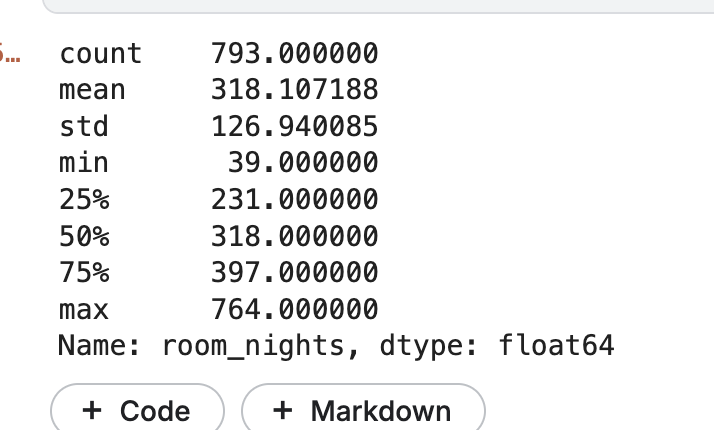
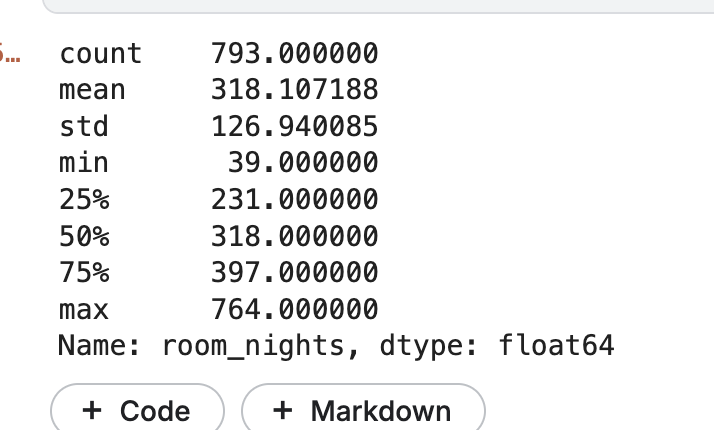

Relación ADR vs Demanda# 

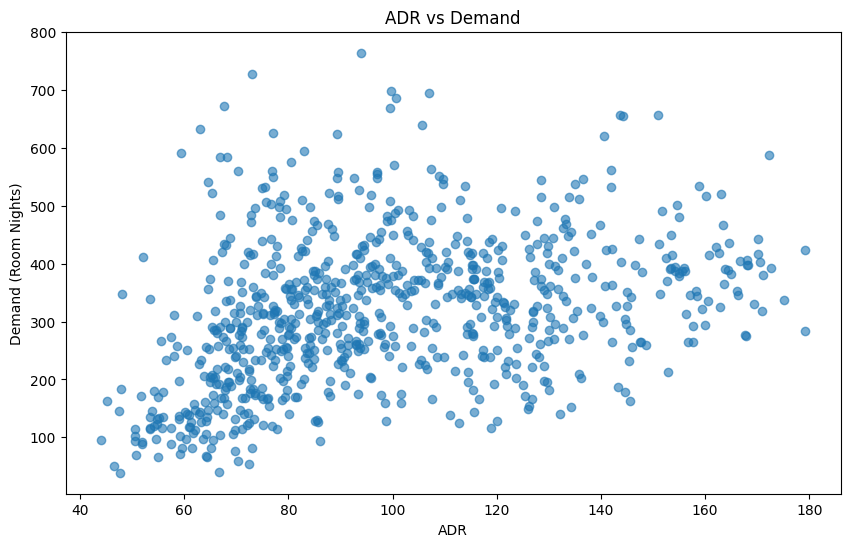

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(daily["ADR"], daily["room_nights"], alpha=0.6)

plt.xlabel("ADR")
plt.ylabel("Demand (Room Nights)")
plt.title("ADR vs Demand")

plt.show()

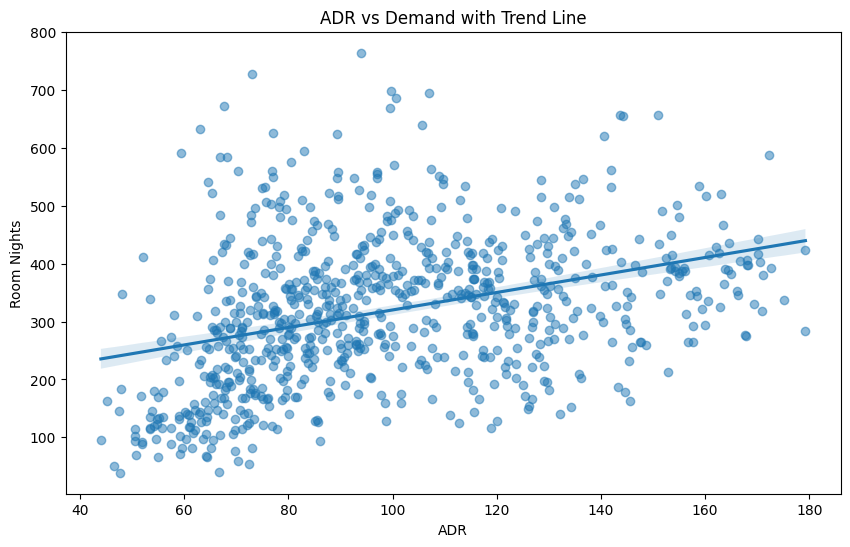

In [22]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.regplot(
    x="ADR",
    y="room_nights",
    data=daily,
    scatter_kws={"alpha":0.5}
)

plt.title("ADR vs Demand with Trend Line")
plt.xlabel("ADR")
plt.ylabel("Room Nights")

plt.show()

The positive relationship suggests that pricing tends to increase during periods of stronger demand.
But an important question arises:
Could we have raised the price more during those days?
Demand variability suggests that price alone does not fully explain booking volume, indicating the influence of seasonality, events, and customer segments.

# ADR vs Demand Regression Model

create logarithmic variables

In [23]:
daily["log_demand"] = np.log(daily["room_nights"])
daily["log_adr"] = np.log(daily["ADR"])

In [24]:
model = smf.ols("log_demand ~ log_adr", data=daily).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     211.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.27e-42
Time:                        18:15:34   Log-Likelihood:                -432.43
No. Observations:                 793   AIC:                             868.9
Df Residuals:                     791   BIC:                             878.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4199      0.224     10.813      0.0

log_adr 0.7140
If the ADR increases by 1%, demand increases by 0.71%. This demonstrates a demand-responsive pricing strategy.The positive elasticity suggests that ADR tends to increase during periods of strong demand. This likely reflects dynamic pricing behavior rather than price causing demand increases.
R-squared: 0.211
The model explains 21% of the variation in demand.
This is because there are more variables that determine demand; we cannot rely solely on a pricing strategy to increase demand.
P>|t| 0.000
It has a statistically significant effect; the price-demand relationship is not random.

# Elasticity by season
Objective: To see how the relationship between ADR and demand changes depending on the season.

In [25]:
model_season = smf.ols("log_demand ~ log_adr + C(season)", data=daily).fit()

print(model_season.summary())

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     90.48
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.50e-50
Time:                        18:15:34   Log-Likelihood:                -409.11
No. Observations:                 793   AIC:                             826.2
Df Residuals:                     789   BIC:                             844.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.10

The regression results suggest that ADR tends to increase during periods of stronger demand, indicating the presence of dynamic pricing behavior. Once seasonality is included in the model, the explanatory power improves (R² increases from 0.21 to 0.26), confirming that seasonal patterns are an important driver of hotel demand.

The results also show that demand is significantly lower during low season compared to high season, while shoulder season maintains relatively strong demand levels.

Overall, the analysis suggests that price alone does not fully explain demand fluctuations, and that revenue management strategies should consider seasonality and market conditions. A deeper analysis by customer segment is required to better understand price sensitivity across different channels.

# Elasticity by segment
Objective: To analyze how the price-demand relationship changes according to the segment.

In [26]:
segment_daily = df.groupby(
    ["arrival_date","season","market_segment"]
).agg({
    "room_nights":"sum",
    "revenue":"sum"
}).reset_index()

In [27]:
segment_daily["ADR"] = segment_daily["revenue"] / segment_daily["room_nights"]
segment_daily.head()

,arrival_date,season,market_segment,room_nights,revenue,ADR
0,2015-07-01,High,Corporate,4,450.42,112.605000
1,2015-07-01,High,Direct,55,4709.06,85.619273
2,2015-07-01,High,Offline TA/TO,194,17099.61,88.142320
3,2015-07-01,High,Online TA,59,6145.67,104.163898
4,2015-07-02,High,Direct,21,2761.00,131.476190


In [28]:
segment_daily.shape

(3505, 6)

In [29]:
segment_daily["log_demand"] = np.log(segment_daily["room_nights"])
segment_daily["log_adr"] = np.log(segment_daily["ADR"])

# NUEVO 👇
segment_daily["log_adr_sq"] = segment_daily["log_adr"] ** 2

In [30]:
model_segment = smf.ols(
    "log_demand ~ log_adr + C(season) + C(market_segment)",
    data=segment_daily
).fit()

print(model_segment.summary())

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     567.2
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:15:34   Log-Likelihood:                -4562.9
No. Observations:                3505   AIC:                             9146.
Df Residuals:                    3495   BIC:                             9207.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# Conclusion — ADR vs. Demand

The analysis shows that hotel demand cannot be explained solely by price, but is heavily influenced by **seasonality and, above all, by customer segmentation**. Including segments in the model significantly increases its explanatory power (R² ≈ 0.59), confirming that the hotel operates in multiple markets with distinct behaviors, not a single homogeneous market.

The estimated elasticity (≈ 0.18) is positive but low, indicating that price is not driving demand, but rather **reacting to it**. In other words, the hotel adjusts its ADR based on market conditions, reflecting an already active dynamic pricing strategy. The reduced elasticity compared to previous models demonstrates that, when controlling for season and segment, the direct effect of price on demand is limited.

Regarding seasonality, the high season acts as a benchmark (coefficient = 0), while the low season shows a significant drop in demand (≈ -0.24). The shoulder season, on the other hand, does not differ significantly from the high season, suggesting a **potential opportunity for price optimization during the shoulder season**.

At the segment level, clear structural differences are observed: channels such as **Online Travel Agencies and Tour Operators** concentrate a large volume of demand, while **Direct and Corporate** provide stability and strategic value. This confirms that the hotel does not have a single demand curve, but rather several, each with a different price sensitivity.

Overall, the results indicate that a single pricing strategy is suboptimal. True revenue optimization requires an approach based on **price, season, and segment**, moving towards models where inventory and pricing are managed differently by customer type, in line with the practices of advanced Revenue Management systems.

# Elasticity by segment in each season: low, medium, and high

In [31]:
segment_daily.groupby(["season","market_segment"]).size().sort_values()

season    market_segment
Shoulder  Complementary       7
High      Complementary       9
Low       Aviation           15
High      Aviation           32
Low       Complementary      32
Shoulder  Aviation           47
High      Groups            111
Low       Groups            129
Shoulder  Groups            131
          Corporate         150
          Offline TA/TO     184
          Direct            184
          Online TA         184
High      Corporate         207
Low       Corporate         257
          Offline TA/TO     302
          Direct            303
          Online TA         303
High      Online TA         306
          Direct            306
          Offline TA/TO     306
dtype: int64

In [32]:
valid_segments = ["Groups", "Corporate", "Direct", "Online TA", "Offline TA/TO"]

filtered_df = segment_daily[
    segment_daily["market_segment"].isin(valid_segments)
]

In [33]:
import statsmodels.api as sm

elasticity_results = []

for season in filtered_df["season"].unique():
    
    for segment in filtered_df["market_segment"].unique():
        
        subset = filtered_df[
            (filtered_df["season"] == season) &
            (filtered_df["market_segment"] == segment)
        ].copy()
        
        if len(subset) < 50:  # subimos el mínimo (mejor calidad)
            continue
        
        X = sm.add_constant(subset["log_adr"])
        y = subset["log_demand"]
        
        model = sm.OLS(y, X).fit()
        
        elasticity_results.append({
            "season": season,
            "segment": segment,
            "elasticity": model.params["log_adr"],
            "r2": model.rsquared,
            "n_obs": len(subset)
        })

In [34]:
elasticity_df = pd.DataFrame(elasticity_results)

pivot = elasticity_df.pivot_table(
    index="segment",
    columns="season",
    values="elasticity"
)

pivot

season,High,Low,Shoulder
segment,,,
Corporate,-0.507339,-0.405019,0.246635
Direct,0.698288,0.534151,0.370222
Groups,-0.710659,0.419908,-0.003356
Offline TA/TO,-0.859882,0.345620,-0.352731
Online TA,1.270232,1.984744,0.385805



# **Revenue Management Elasticity Analysis Report**

## **1. Corporate Segment**

### **Results**

* High: **-0.50**
* Low: **-0.40**
* Shoulder: **+0.25**

---

### **Technical Interpretation**

The Corporate segment exhibits **consistently low elasticity in absolute terms**, with minor variation across seasons:

* Moderate negative elasticity in High and Low periods
* Slight positive elasticity in Shoulder

---

### **Economic Meaning**

This indicates that:

> Corporate demand is **relatively price inelastic**

In practical terms:

* Changes in ADR generate **limited variation in booking volume**
* Purchase decisions are **less driven by price sensitivity**

---

### **Structural Drivers**

This behavior aligns with the intrinsic characteristics of the segment:

* Travel driven by necessity (business vs leisure)
* Lower price sensitivity
* Frequent bookings under corporate agreements or internal policies

The positive elasticity in Shoulder suggests:

> Price is reacting to demand rather than driving it

---

### **Pricing Strategy**

**High Season**

* Gradual price increases
* Limited volume loss → strong revenue uplift

**Low Season**

* Maintain relatively firm pricing
* Avoid unnecessary discounting

**Shoulder**

* Demand-led pricing approach
* Focus on dynamic adjustments rather than promotions

---

# **2. Direct Channel**

### **Results**

* High: **+0.69**
* Low: **+0.53**
* Shoulder: **+0.37**

---

### **Technical Interpretation**

Positive elasticity across all seasons.

---

### **Economic Meaning**

> There is no direct causal relationship between price and demand

The Direct channel reflects:

* Existing demand
* Limited direct price sensitivity

---

### **Structural Drivers**

* High booking intent customers
* Brand trust outweighs price considerations
* Captures demand generated through other channels

---

### **Pricing Strategy**

**Overall Approach**

* Avoid price competition
* Do not rely on systematic discounting

**Strategic Priority**

* Conversion optimization:

  * Website UX
  * Loading speed
  * Offer clarity

**High Demand Periods**

* Increase prices with minimal risk to conversion

---

# **3. Groups Segment**

### **Results**

* High: **-0.71**
* Low: **+0.42**
* Shoulder: **≈ 0**

---

### **Technical Interpretation**

* High elasticity in High season
* Non-linear behavior in Low and Shoulder

---

### **Economic Meaning**

**High Season**

> Strong price sensitivity

* Small ADR changes → large volume fluctuations

**Low Season**

> Positive elasticity → non-causal relationship

* Demand driven by negotiation, contracts, and availability

---

### **Structural Drivers**

* Highly planned segment
* Budget constraints
* Pricing often pre-negotiated

---

### **Pricing Strategy**

**High Season**

* Restrict group availability
* Increase prices aggressively
* Prioritize higher-yield segments

**Low Season**

* Use groups to drive occupancy
* Accept volume at lower rates

**Shoulder**

* Case-by-case evaluation
* Hybrid strategy

---

# **4. Offline TA / Tour Operators**

### **Results**

* High: **-0.86**
* Shoulder: **-0.35**
* Low: **+0.34**

---

### **Technical Interpretation**

* High elasticity in High season
* Moderate elasticity in Shoulder
* Non-causal relationship in Low

---

### **Economic Meaning**

**High Season**

> Highly price-sensitive segment

* ADR increases → significant drop in volume

---

### **Structural Drivers**

* Tight contract margins
* Strong competition across destinations
* End customers are price-sensitive

---

### **Pricing Strategy**

**High Season**

* Limit availability
* Increase prices or close sales
* Prevent displacement of higher-value demand

**Low Season**

* Key driver of base occupancy
* Use as volume stabilizer

---

# **5. Online Travel Agencies (OTA)**

### **Results**

* High: **+1.27**
* Low: **+1.98**
* Shoulder: **+0.38**

---

### **Technical Interpretation**

High positive elasticity across all periods.

---

### **Economic Meaning**

> Does not measure price sensitivity
> Reflects price reacting to demand

---

### **Structural Drivers**

* Dynamic pricing aligned with demand
* High visibility during peak periods
* Captures incremental demand

---

### **Pricing Strategy**

**High Season**

* Reduce dependency
* Control inventory allocation
* Prioritize direct channels

**Overall**

* Use as a demand absorption channel
* Not as a primary revenue driver

---





# **6. Strategic Global Insight**

> Price sensitivity is not homogeneous and varies significantly by segment and season. Contract-driven segments (Groups, Offline TA/TO) show a more direct relationship with price, while dynamic channels (Direct, OTA) primarily reflect demand conditions rather than causality.

---

# **7. Key Strategic Implications**

### **1. Pricing Power in High Demand**

Opportunity to increase ADR in:

* Corporate
* Direct
* OTA (controlled exposure)

→ Maximize revenue with limited volume impact

---

### **2. Inventory Protection**

Reduce exposure to:

* Groups
* Offline TA / TO

→ Avoid revenue dilution and displacement

---

### **3. Base Strategy in Low Demand**

Leverage for occupancy:

* Groups
* Offline TA / TO

→ Stabilize revenue during weak periods

---

# **Executive Conclusion**

> The analysis confirms that pricing strategy must be both segment-specific and season-dependent. While certain segments enable price optimization during peak demand, others must be strategically constrained to prevent revenue dilution. Effective revenue management requires balancing pricing power with optimal channel mix allocation.
